# 4.3 (KAN-11): Apply PCA

Parent: **Task 3 (KAN-6)**. Input: `data/features_panel.csv` from 4.2 (KAN-10).

**Why PCA:** 4.2 found strong multicollinearity (19 feature pairs with |r| > 0.9; 23 of 38 features with VIF > 10). PCA replaces the 38 correlated numeric features with a smaller set of **uncorrelated** components for the linear model (logistic regression). Tree models can keep using the raw features.

**Leakage rule:** the scaler and PCA are **fit on the training weeks only** and then applied to the test weeks.

**Outputs**
- `models/pca_pipeline.joblib`: fitted `StandardScaler → PCA` pipeline
- `data/features_pca.csv`: keys, categoricals, principal components, targets and split
- Charts in `reports/figures/task4/`

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
from build_features import KEYS, NUMERIC_FEATURES, TARGETS

DATA, MODELS = ROOT / "data", ROOT / "models"
FIG = ROOT / "reports" / "figures" / "task4"
MODELS.mkdir(exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)

INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"
DIR_COLORS = {"fall": "#2a78d6", "flat": "#898781", "rise": "#eb6834"}
DIV = LinearSegmentedColormap.from_list("div_blue_red", ["#184f95", "#6da7ec", "#f0efec", "#ec8a89", "#b52e2e"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e1",
    "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

feats = pd.read_csv(DATA / "features_panel.csv", parse_dates=["week_start_date"])
train, test = feats[feats["split"] == "train"], feats[feats["split"] == "test"]
print("train:", train.shape, "| test:", test.shape, "| numeric features:", len(NUMERIC_FEATURES))

train: (6720, 46) | test: (2310, 46) | numeric features: 38


## 1. Fit standardisation + PCA on the training weeks

In [2]:
full = make_pipeline(StandardScaler(), PCA(random_state=42)).fit(train[NUMERIC_FEATURES])
pca_full = full.named_steps["pca"]
ev = pca_full.explained_variance_ratio_
cum = ev.cumsum()

thresholds = {t: int(np.searchsorted(cum, t) + 1) for t in (0.80, 0.90, 0.95)}
kaiser = int((pca_full.explained_variance_ > 1).sum())
print("Components needed:", {f"{int(t*100)}%": k for t, k in thresholds.items()})
print("Kaiser rule (eigenvalue > 1):", kaiser)
pd.DataFrame({"explained_var": ev, "cumulative": cum},
             index=[f"PC{i+1}" for i in range(len(ev))]).head(16).round(3)

Components needed: {'80%': 9, '90%': 14, '95%': 17}
Kaiser rule (eigenvalue > 1): 9


,explained_var,cumulative
PC1,0.216,0.216
PC2,0.139,0.356
PC3,0.123,0.478
PC4,0.106,0.585
PC5,0.070,0.655
PC6,0.050,0.705
PC7,0.044,0.750
PC8,0.033,0.782
PC9,0.029,0.811
PC10,0.025,0.836


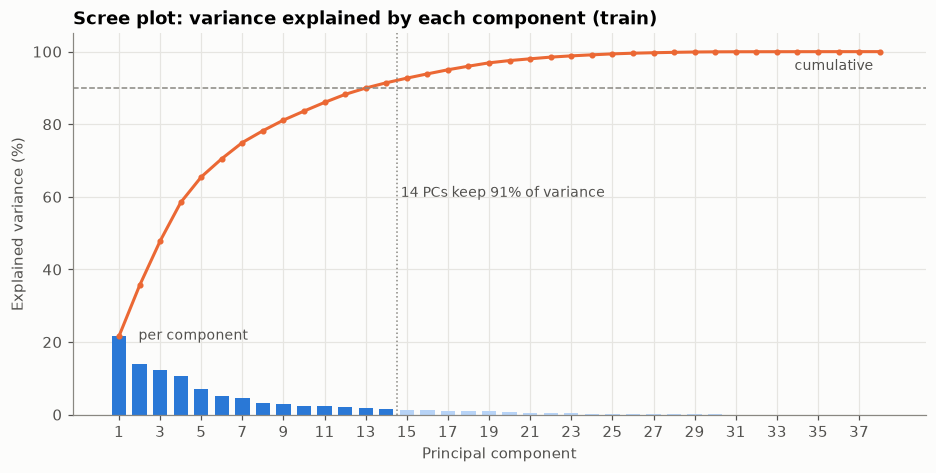

In [3]:
N_COMPONENTS = thresholds[0.90]

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(1, len(ev) + 1)
ax.bar(x, ev * 100, color=[BLUE if i <= N_COMPONENTS else "#b7d3f6" for i in x], width=0.7)
ax.plot(x, cum * 100, color=ORANGE, lw=2, marker="o", ms=3)
ax.axhline(90, color=MUTED, lw=1, ls="--")
ax.axvline(N_COMPONENTS + 0.5, color=MUTED, lw=1, ls=":")
ax.annotate(f"{N_COMPONENTS} PCs keep {cum[N_COMPONENTS-1]:.0%} of variance",
            (N_COMPONENTS + 0.7, 60), color=INK2, fontsize=9)
ax.annotate("cumulative", (x[-1], cum[-1] * 100), xytext=(-4, -12), textcoords="offset points",
            ha="right", color=INK2, fontsize=9)
ax.annotate("per component", (1.5, ev[0] * 100), xytext=(6, 0), textcoords="offset points",
            color=INK2, fontsize=9, va="center")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance (%)")
ax.set_xticks(x[::2])
ax.set_title("Scree plot: variance explained by each component (train)")
fig.savefig(FIG / "pca_scree.png"); plt.show()

**Choice:** keep the components that explain **90%** of the variance. This is the smallest set that keeps most of the information while removing the redundancy among the price-level, rolling-mean and calendar features. The Kaiser rule (eigenvalue > 1) would keep fewer, and is reported for comparison.

## 2. Interpret the components (loadings)

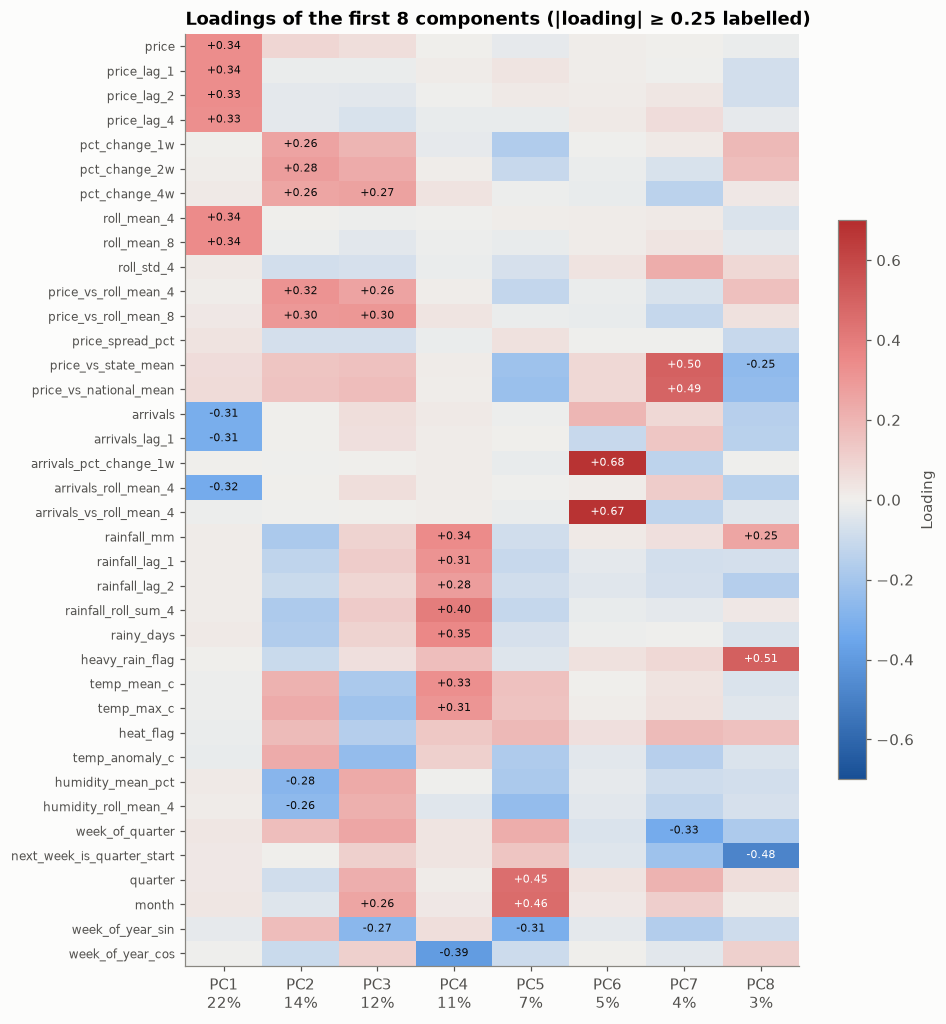

PC1: roll_mean_4 (+0.34), roll_mean_8 (+0.34), price (+0.34), price_lag_1 (+0.34), price_lag_2 (+0.33)
PC2: price_vs_roll_mean_4 (+0.32), price_vs_roll_mean_8 (+0.30), pct_change_2w (+0.28), humidity_mean_pct (-0.28), pct_change_1w (+0.26)
PC3: price_vs_roll_mean_8 (+0.30), week_of_year_sin (-0.27), pct_change_4w (+0.27), price_vs_roll_mean_4 (+0.26), month (+0.26)
PC4: rainfall_roll_sum_4 (+0.40), week_of_year_cos (-0.39), rainy_days (+0.35), rainfall_mm (+0.34), temp_mean_c (+0.33)
PC5: month (+0.46), quarter (+0.45), week_of_year_sin (-0.31), humidity_roll_mean_4 (-0.24), price_vs_national_mean (-0.23)
PC6: arrivals_pct_change_1w (+0.68), arrivals_vs_roll_mean_4 (+0.67), arrivals (+0.19), arrivals_lag_1 (-0.10), price_vs_national_mean (+0.08)
PC7: price_vs_state_mean (+0.50), price_vs_national_mean (+0.49), week_of_quarter (-0.33), roll_std_4 (+0.23), next_week_is_quarter_start (-0.22)
PC8: heavy_rain_flag (+0.51), next_week_is_quarter_start (-0.48), price_vs_state_mean (-0.25), rai

In [4]:
pipe = make_pipeline(StandardScaler(), PCA(n_components=N_COMPONENTS, random_state=42)).fit(train[NUMERIC_FEATURES])
pca = pipe.named_steps["pca"]
pc_names = [f"PC{i+1}" for i in range(N_COMPONENTS)]
loadings = pd.DataFrame(pca.components_.T, index=NUMERIC_FEATURES, columns=pc_names)

SHOW = 8
fig, ax = plt.subplots(figsize=(9, 11))
im = ax.imshow(loadings.iloc[:, :SHOW].values, cmap=DIV, vmin=-0.7, vmax=0.7, aspect="auto")
ax.set_yticks(range(len(loadings)), loadings.index, fontsize=8)
ax.set_xticks(range(SHOW), [f"{c}\n{ev[i]:.0%}" for i, c in enumerate(pc_names[:SHOW])])
ax.grid(False)
for (i, j), v in np.ndenumerate(loadings.iloc[:, :SHOW].values):
    if abs(v) >= 0.25:
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=7,
                color="#ffffff" if abs(v) > 0.45 else INK)
fig.colorbar(im, ax=ax, shrink=0.6, label="Loading")
ax.set_title(f"Loadings of the first {SHOW} components (|loading| ≥ 0.25 labelled)")
fig.savefig(FIG / "pca_loadings_heatmap.png"); plt.show()

for c in pc_names[:SHOW]:
    top = loadings[c].sort_values(key=abs, ascending=False).head(5)
    print(f"{c}: " + ", ".join(f"{f} ({v:+.2f})" for f, v in top.items()))

**Interpretation of the leading components** (sign is arbitrary in PCA; what matters is which features load together):

| PC | Variance | Main loadings | Meaning |
|---|---|---|---|
| PC1 | ≈ 22% | price, its lags, rolling means | **Price level**: how dear the crop is in this mandi (largely crop identity) |
| PC2 | ≈ 14% | price vs rolling means, 1-2 week % change, humidity (−) | **Short-term price momentum** |
| PC3 | ≈ 12% | 4-week % change, price vs 8-week mean, week of quarter, month | **Position in the quarterly price cycle** |
| PC4 | ≈ 11% | rainfall (week, lag, 4-week sum), rainy days, temperature | **Wet / monsoon weather** |
| PC5 | ≈ 7% | month, quarter, week-of-year | **Time of year** |
| PC6 | ≈ 5% | arrivals % change, arrivals vs 4-week mean | **Supply shock** |
| PC7 | ≈ 4% | price vs state and national mean | **Local price premium/discount** |
| PC8 | ≈ 3% | heavy-rain flag, next week is quarter start (−) | **Extreme rain / quarter-turn events** |

## 3. Transform train and test; check the components

In [5]:
Z_train = pd.DataFrame(pipe.transform(train[NUMERIC_FEATURES]), columns=pc_names, index=train.index)
Z_test = pd.DataFrame(pipe.transform(test[NUMERIC_FEATURES]), columns=pc_names, index=test.index)

off = lambda m: np.abs(m.values[~np.eye(len(m), dtype=bool)]).max()
print(f"Max |corr| between PCs - train: {off(Z_train.corr()):.3f}, test: {off(Z_test.corr()):.3f}")
print("Train PCs are uncorrelated by construction.")
zc = Z_test.corr().where(np.triu(np.ones((N_COMPONENTS, N_COMPONENTS), bool), 1)).stack()
print("Most correlated PC pairs in the test quarter:")
print(zc.sort_values(key=abs, ascending=False).head(4).round(2).to_string())
print("\nCalendar coverage - train months:", sorted(train["month"].unique().tolist()),
      "| test months:", sorted(test["month"].unique().tolist()),
      "| training weeks in Q3:", train.loc[train["quarter"] == 3, "week_start_date"].nunique())

rho = Z_train.corrwith(train["target_pct_change"], method="spearman")
print("\nSpearman rho of each PC with next week's % price change (train):")
print(rho.round(3).to_string())

Max |corr| between PCs - train: 0.000, test: 0.870
Train PCs are uncorrelated by construction.
Most correlated PC pairs in the test quarter:
PC4  PC5    -0.87
PC2  PC4    -0.83
PC4  PC12    0.83
PC8  PC9     0.78

Calendar coverage - train months: [1, 2, 3, 4, 5, 6, 7, 11, 12] | test months: [7, 8, 9] | training weeks in Q3: 1

Spearman rho of each PC with next week's % price change (train):
PC1    -0.099
PC2    -0.259
PC3    -0.374
PC4    -0.035
PC5     0.079
PC6    -0.026
PC7    -0.069
PC8     0.190
PC9    -0.151
PC10   -0.065
PC11   -0.156
PC12   -0.059
PC13   -0.177
PC14    0.041


**Caveat: the test quarter is outside the training season.** With only one year of data, training covers late Nov to early Jul and the test set is a single quarter (Q3, Jul-Sep, the monsoon). Only one training week (2026-06-29) falls in Q3, and August and September are not seen at all. Inside that quarter, the season-related inputs (month, week-of-year, rainfall, humidity) move together, so the components built from them (PC4, PC5, PC12) become strongly correlated on the test set, even though they are uncorrelated on train. This is distribution shift, not a PCA bug, but it matters for Task 5:
- year-calendar features (`month`, `quarter`, `week_of_year_sin/cos`) cannot generalise from one year of data. Consider dropping them from the model and relying on `week_of_quarter` / `next_week_is_quarter_start`, which repeat every quarter;
- use **rolling-origin time-series cross-validation** across several quarters, not only this single hold-out quarter.

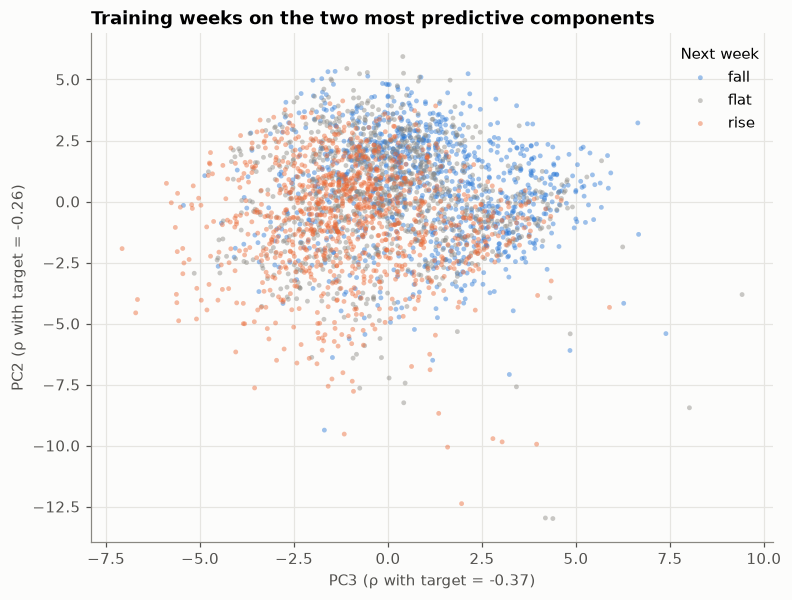

In [6]:
top2 = rho.abs().sort_values(ascending=False).index[:2]
sample = Z_train.join(train["target_direction"]).sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 6))
for d, col in DIR_COLORS.items():
    s = sample[sample["target_direction"] == d]
    ax.scatter(s[top2[0]], s[top2[1]], s=10, alpha=0.45, color=col, label=d, edgecolors="none")
ax.set_xlabel(f"{top2[0]} (ρ with target = {rho[top2[0]]:+.2f})")
ax.set_ylabel(f"{top2[1]} (ρ with target = {rho[top2[1]]:+.2f})")
ax.legend(title="Next week", frameon=False)
ax.set_title("Training weeks on the two most predictive components")
fig.savefig(FIG / "pca_top2_components_by_direction.png"); plt.show()

## 4. Save the pipeline and the PCA feature table

In [7]:
joblib.dump(pipe, MODELS / "pca_pipeline.joblib")
pca_table = pd.concat([feats[KEYS + TARGETS + ["split"]],
                       pd.concat([Z_train, Z_test]).loc[feats.index].round(6)], axis=1)
pca_table.to_csv(DATA / "features_pca.csv", index=False)
loadings.round(4).to_csv(ROOT / "reports" / "pca_loadings.csv")
print("Saved models/pca_pipeline.joblib, data/features_pca.csv", pca_table.shape, "and reports/pca_loadings.csv")

Saved models/pca_pipeline.joblib, data/features_pca.csv (9030, 22) and reports/pca_loadings.csv


## 5. Summary

- 38 correlated numeric features were reduced to **14 uncorrelated principal components** that keep **90%** of the training variance. The scaler and PCA were fit on the training weeks only.
- The leading components are interpretable: **price level**, **short-term momentum**, **position in the quarterly cycle**, **wet weather**, **time of year**, **supply shock** and **local premium**.
- The components most related to next week's move are **PC3 (quarterly cycle)** and **PC2 (momentum)**, in line with the EDA finding that the calendar and mean reversion drive weekly moves. The weather component (PC4) is only weakly related.
- On the test quarter (Q3, Jul-Sep, almost absent from the training data) some components become correlated because the season-related inputs shift together, a consequence of having only one year of data. Task 5 should consider dropping the year-calendar features and use rolling-origin CV.
- **Next step (Task 5: model development):** logistic regression on the PCs + `crop`/`state` one-hot; tree models on the raw 38 features. Compare both against the naive baseline on the same chronological test quarter.